Accuracy: 0.9743589743589743

Classification Report:
               precision    recall  f1-score   support

     class_0       1.00      0.94      0.97        17
     class_1       0.96      1.00      0.98        22

    accuracy                           0.97        39
   macro avg       0.98      0.97      0.97        39
weighted avg       0.98      0.97      0.97        39

Precision: 0.96
Recall: 1.00
F1 Score: 0.98


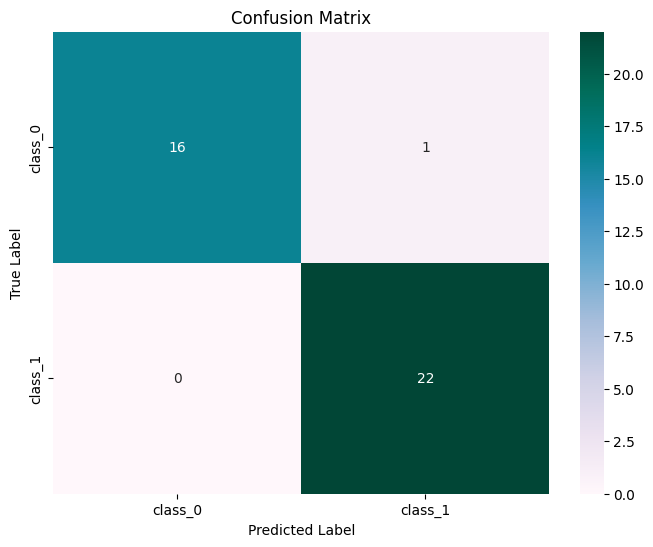

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Load the Wine dataset
wine = load_wine()

# Create DataFrame
data = pd.DataFrame(data=wine.data, columns=wine.feature_names)
data['Target'] = wine.target

# Keep only two classes (0 and 1)
data = data[data['Target'] != 2]

# Features and target
X = data.drop('Target', axis=1)
y = data['Target']

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1
)

# Train Decision Tree classifier
model = DecisionTreeClassifier(random_state=1)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

class_report = classification_report(
    y_test,
    y_pred,
    target_names=wine.target_names[:2]
)
print("\nClassification Report:\n", class_report)

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',
    cmap='PuBuGn',
    xticklabels=wine.target_names[:2],
    yticklabels=wine.target_names[:2]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()